<a href="https://colab.research.google.com/github/maker-arch/D2LExercises/blob/main/automatic_differentiation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import torch

In [14]:
# 初始化
x = torch.arange(4.0)
x

tensor([0., 1., 2., 3.])

In [15]:
x.requires_grad_(True)
x.grad

In [16]:
y = 2 * torch.dot(x,x)
y

tensor(28., grad_fn=<MulBackward0>)

In [18]:
y.backward()
x.grad

RuntimeError: Trying to backward through the graph a second time (or directly access saved tensors after they have already been freed). Saved intermediate values of the graph are freed when you call .backward() or autograd.grad(). Specify retain_graph=True if you need to backward through the graph a second time or if you need to access saved tensors after calling backward.

In [7]:
x.grad == 4 * x

tensor([True, True, True, True])

In [9]:
x.grad.zero_()
y = x.sum()
y.backward()
print(y)
x.grad

tensor(6., grad_fn=<SumBackward0>)


tensor([1., 1., 1., 1.])

In [12]:
x.grad.zero_()
y = x * x
y.sum().backward() #更快
# y.backward(gradient=torch.ones(len(y)))
x.grad

tensor([0., 2., 4., 6.])

In [17]:
x.grad.zero_()
y = x * x
u = y.detach()
z = u * x
z.sum().backward() #一定要记得sum，只能scalar backward
x.grad == u

tensor([True, True, True, True])

In [1]:
def f(a):
  b = a * 2
  while b.norm() < 1000:
    b = b * 2
  if b.sum() > 0:
    c = b
  else:
    c = 100 * b
  return c

In [23]:
a = torch.randn(size=(), requires_grad=True)
d = f(a)
print(f'a:{a}, d: {d}')
d.backward()
a.grad == d/a

a:0.7885906100273132, d: 1615.0335693359375


tensor(True)

In [4]:
a.grad == d/a

tensor(True)

In [19]:
#exersise
1、Why is the second derivative much more expensive to compute than the first derivative?
计算两次？存储多？

2、After running the function for backpropagation, immediately run it again and see what happens. Investigate.
报错，Trying to backward through the graph a second time (or directly access saved tensors after they have already been freed). Saved intermediate values of the graph are freed when you call .backward() or autograd.grad(). Specify retain_graph=True if you need to backward through the graph a second time or if you need to access saved tensors after calling backward.

3、In the control flow example where we calculate the derivative of d with respect to a, what would happen if we changed the variable a to a random vector or a matrix? At this point, the result of the calculation f(a) is no longer a scalar. What happens to the result? How do we analyze this?
报错，RuntimeError: grad can be implicitly created only for scalar outputs。需要变成
d.sum().backward()

SyntaxError: invalid character '？' (U+FF1F) (2984903993.py, line 3)

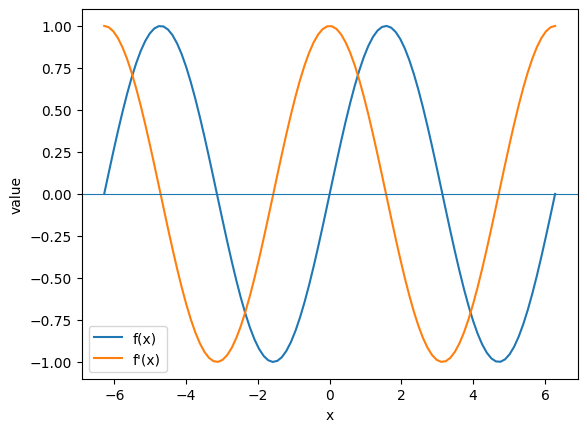

In [29]:
# 第5题
import matplotlib.pyplot as plt

x = torch.linspace(-2*torch.pi, 2*torch.pi, 100, requires_grad=True)

y = torch.sin(x)

y.sum().backward()

x.grad

plt.plot(
    x.detach().numpy(),
    y.detach().numpy(),
    label='f(x)'
)

plt.plot(
    x.detach().numpy(),
    x.grad.detach().numpy(),
    label="f'(x)"
)

plt.axhline(0, linewidth=0.8)
plt.xlabel('x')
plt.ylabel('value')
plt.legend()
plt.show()

In [31]:
x = torch.tensor(2.0, requires_grad=True)
a = x ** 2
b = torch.log(a)
c = torch.sin(x)

d = b * c

e = x ** (-1)

f = d + e

f.backward()
print("f =", f)
print("df/dx =", x.grad)

f = tensor(1.7606, grad_fn=<AddBackward0>)
df/dx = tensor(0.0824)


In [34]:
x = torch.arange(4.0, requires_grad=True)
y = 2 * torch.dot(x, x)
y.backward()

print(x)
print(y)
print(x.grad)

tensor([0., 1., 2., 3.], requires_grad=True)
tensor(28., grad_fn=<MulBackward0>)
tensor([ 0.,  4.,  8., 12.])


In [35]:
x = torch.arange(4.0, requires_grad=True)

y = 2 * torch.dot(x, x)
y.backward()
print(x.grad)

y = 2 * torch.dot(x, x)
y.backward()
print(x.grad)

tensor([ 0.,  4.,  8., 12.])
tensor([ 0.,  8., 16., 24.])
